## Import libraries

In [8]:
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
import sys, os

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score

sys.path.insert(0, os.path.abspath('..'))   # so max_heap.py is importable
from max_heap import MaxHeap, euclidean_distance

# Load data

In [9]:
from scripts.utils import load_data
df = load_data()

Loading from c:\Users\gus7h\OneDrive\Documents\Hertie\2025-2026\Data Structures and Algorithms\project-chaggg\data\cleaned\chicago_crimes_cleaned.parquet...


In [28]:
df.head(3)

,id,case_number,date,block,iucr,primary_type,description,location_description,arrest,domestic,...,hour,minute,hour_sin,hour_cos,day_of_week_sin,day_of_week_cos,month_sin,month_cos,day_of_year_sin,day_of_year_cos
0,1969564,HH162926,2002-01-01,063XX N WASHTENAW AV,0820,THEFT,$500 AND UNDER,STREET,False,False,...,0,0,0.0,1.0,0.781831,0.62349,0.5,0.866025,0.017213,0.999852
1,1921971,HH105505,2002-01-01,085XX S CRANDON AV,1310,CRIMINAL DAMAGE,TO PROPERTY,RESIDENCE,False,False,...,0,0,0.0,1.0,0.781831,0.62349,0.5,0.866025,0.017213,0.999852
2,1989110,HH188541,2002-01-01,047XX N HERMITAGE AV,0820,THEFT,$500 AND UNDER,RESIDENCE,False,False,...,0,0,0.0,1.0,0.781831,0.62349,0.5,0.866025,0.017213,0.999852


In [10]:
df.shape

(7898407, 36)

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7898407 entries, 0 to 7898406
Data columns (total 36 columns):
 #   Column                Dtype  
---  ------                -----  
 0   id                    int64  
 1   case_number           str    
 2   date                  str    
 3   block                 str    
 4   iucr                  str    
 5   primary_type          str    
 6   description           str    
 7   location_description  str    
 8   arrest                bool   
 9   domestic              bool   
 10  beat                  int64  
 11  district              float64
 12  ward                  float64
 13  community_area        float64
 14  fbi_code              str    
 15  year                  int64  
 16  updated_on            str    
 17  x_coordinate          float64
 18  y_coordinate          float64
 19  latitude              float64
 20  longitude             float64
 21  time                  str    
 22  month                 int64  
 23  day               

In [27]:
crime_types = df['primary_type'].value_counts().to_list
crime_types

<bound method IndexOpsMixin.tolist of primary_type
THEFT                                1680404
BATTERY                              1444207
CRIMINAL DAMAGE                       903471
NARCOTICS                             701922
ASSAULT                               535128
OTHER OFFENSE                         494637
BURGLARY                              420079
MOTOR VEHICLE THEFT                   403983
DECEPTIVE PRACTICE                    354957
ROBBERY                               295780
CRIMINAL TRESPASS                     213584
WEAPONS VIOLATION                     120991
PROSTITUTION                           63772
OFFENSE INVOLVING CHILDREN             54123
PUBLIC PEACE VIOLATION                 51992
SEX OFFENSE                            30240
CRIM SEXUAL ASSAULT                    24046
INTERFERENCE WITH PUBLIC OFFICER       19921
LIQUOR LAW VIOLATION                   13676
GAMBLING                               13635
ARSON                                  13395
HOMI

# Some graphs

In [16]:
## LOOK AT THIS:

# --- Hello -----------------------
total_cases_per_district_per_year = df.groupby(['district', 'year']).agg(total_cases = ('case_number', 'nunique'))

arrest_in_case = df.groupby('case_number').agg(arrests = ('arrest', 'sum'))

columns_of_interest=['year', 'district', 'case_number']
df_cols = df[columns_of_interest].drop_duplicates()

df_graph1 = pd.merge(df_cols, arrest_in_case, on='case_number', how='left')
df_graph1['had_arrest'] = np.where(
    df_graph1['arrests'] > 0, 1, 0)


In [17]:
# --- Checking if it works:

df_graph1.sort_values(by=['year', 'district', 'case_number'])

# It did :)

,year,district,case_number,arrests,had_arrest
73928,2002,1.0,G128688,1,1
23281,2002,1.0,G760587,1,1
23225,2002,1.0,G760590,1,1
147321,2002,1.0,HH000000,0,0
207158,2002,1.0,HH000191,1,1
...,...,...,...,...,...
7700352,2025,31.0,JJ172679,1,1
7721331,2025,31.0,JJ213829,0,0
7742317,2025,31.0,JJ252525,0,0
7746340,2025,31.0,JJ260308,1,1


In [18]:
## Final table

df_graph1 = df_graph1.groupby(['year','district']).agg(total_cases = ('case_number','count'),
                                                       total_atleastonearrest = ('had_arrest', 'sum'))
df_graph1['had_arrest_rate'] = df_graph1['total_atleastonearrest'] / df_graph1['total_cases']
df_graph1 = df_graph1.reset_index()

I want to graph, for each district, the proportion of cases in which at least one arrest ocurred per year:

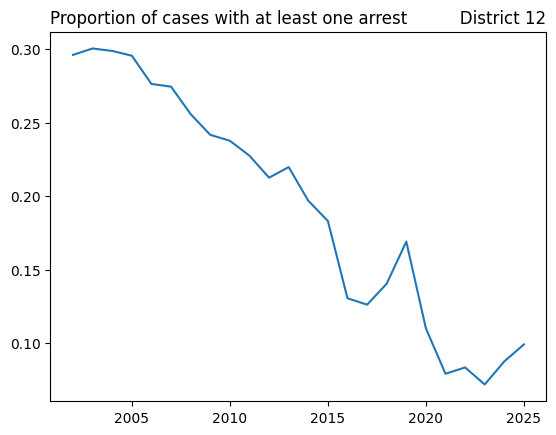

In [19]:
# As it is now, you need to change the district manually:

plt.plot(df_graph1['year'][df_graph1['district']==12], df_graph1['had_arrest_rate'][df_graph1['district']==12])
plt.title('Proportion of cases with at least one arrest\
          District 12')
plt.show()

Put differently, I now graph, for each year, the proportion of cases that involved at least one arrest per district.

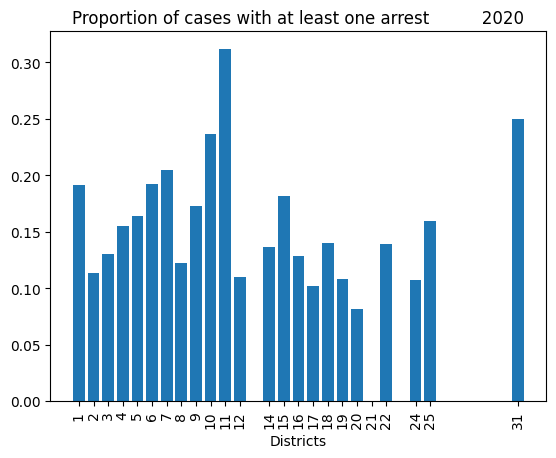

In [20]:
# As it is now, you need to change the year manually:

plt.bar(df_graph1['district'][df_graph1['year']==2020], df_graph1['had_arrest_rate'][df_graph1['year']==2020])
plt.title('Proportion of cases with at least one arrest\
          2020')
plt.xlabel('Districts')
plt.xticks(ticks = df_graph1['district'].unique(), rotation = 90)
plt.show()

# KNN + Ridge Regression — Predicting Arrest

In [21]:
# ── target ────────────────────────────────────────────────────────────────────
df['arrest_int'] = df['arrest'].astype(int)

# ── other numeric features ────────────────────────────────────────────────────
df['domestic_int'] = df['domestic'].astype(int)

FEATURES = [
    'time_cyclical',
    'date_cyclical',
    'dow_cyclical',
    'domestic_int',
    'district',
    'x_coordinate',
    'y_coordinate',
]
TARGET = 'arrest_int'

model_df = df[FEATURES + [TARGET]].dropna().reset_index(drop=True)
print(model_df.shape)
model_df.head()

(7897575, 8)


,time_cyclical,date_cyclical,dow_cyclical,domestic_int,district,x_coordinate,y_coordinate,arrest_int
0,0.0,0.0,0.866025,0,24.0,1157181.0,1941908.0,0
1,0.0,0.0,0.866025,0,4.0,1192988.0,1848862.0,0
2,0.0,0.0,0.866025,0,19.0,1163946.0,1931450.0,0
3,0.0,0.0,0.866025,0,25.0,1138221.0,1918236.0,0
4,0.0,0.0,0.866025,0,8.0,1149846.0,1860270.0,0


In [22]:
from sklearn.model_selection import train_test_split

# Use a small sample so KNN is tractable without vectorised distance
SAMPLE_SIZE = 20_000
sample = model_df.sample(SAMPLE_SIZE, random_state=42).reset_index(drop=True)

X = sample[FEATURES].values
y = sample[TARGET].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale — critical for Euclidean distance (KNN is distance-sensitive)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Train: {X_train_s.shape}, Test: {X_test_s.shape}")
print(f"Arrest rate — train: {y_train.mean():.3f}, test: {y_test.mean():.3f}")

Train: (16000, 7), Test: (4000, 7)
Arrest rate — train: 0.248, test: 0.248


In [23]:
def knn_ridge_predict(X_train, y_train, query, k, alpha=1.0):
    """
    Predict a single query point using local ridge regression.

    1. MaxHeap finds the k nearest neighbours in O(n log k).
    2. Ridge regression is fitted on those k points only.
    3. Returns a raw score (not thresholded).
    """
    heap = MaxHeap(capacity=k)

    for i, x in enumerate(X_train):
        dist = euclidean_distance(x.tolist(), query.tolist())
        heap.add(dist, float(i))          # store row index as target

    # Retrieve the k neighbours
    neighbour_indices = [int(target) for _, target in heap.get_all()]
    X_local = X_train[neighbour_indices]
    y_local = y_train[neighbour_indices]

    # Fit ridge on the local neighbourhood
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_local, y_local)

    return ridge.predict(query.reshape(1, -1))[0]


# ── Run on the test set ────────────────────────────────────────────────────────
K     = 30      # number of neighbours
ALPHA = 1.0     # ridge regularisation strength

raw_scores = np.array([
    knn_ridge_predict(X_train_s, y_train, q, k=K, alpha=ALPHA)
    for q in X_test_s
])

# Threshold at 0.5 for binary classification
y_pred = (raw_scores >= 0.5).astype(int)

NameError: name 'MaxHeap' is not defined

In [ ]:
print(classification_report(y_test, y_pred, target_names=['No arrest', 'Arrest']))
print(f"ROC-AUC: {roc_auc_score(y_test, raw_scores):.4f}")

              precision    recall  f1-score   support

   No arrest       0.76      0.97      0.85      2994
      Arrest       0.45      0.08      0.13      1006

    accuracy                           0.74      4000
   macro avg       0.60      0.52      0.49      4000
weighted avg       0.68      0.74      0.67      4000

ROC-AUC: 0.5899


# KNN

## Grace's additional cleaning version 2.0
**Collapsed df s.t. each row is an incident, added three new columns: 1) at least one arrested, 2) how many people involved, 3) probability of arrest for given incident**

In [ ]:
# --- Before collapsing: count people involved per incident ---
people_per_incident = df.groupby('case_number').size().rename('people_involved')

# --- Collapse: one row per incident ---
# For most columns, take the first value (they should be the same across rows of the same incident)
# For 'arrest', take max — True if ANY person was arrested (your binary variable)
incident_df = df.groupby('case_number').agg(
    id=('id', 'first'),
    date=('date', 'first'),
    block=('block', 'first'),
    iucr=('iucr', 'first'),
    primary_type=('primary_type', 'first'),
    description=('description', 'first'),
    location_description=('location_description', 'first'),
    domestic=('domestic', 'first'),
    beat=('beat', 'first'),
    district=('district', 'first'),
    ward=('ward', 'first'),
    community_area=('community_area', 'first'),
    fbi_code = ('fbi_code', 'first'),
    year=('year', 'first'),
    updated_on=('updated_on', 'first'),
    x_coordinate=('x_coordinate', 'first'),
    y_coordinate=('y_coordinate', 'first'),
    latitude=('latitude', 'first'),
    longitude=('longitude', 'first'),
    time=('time', 'first'),
    month=('month', 'first'),
    day=('day', 'first'),
    day_of_week=('day_of_week', 'first'),
    day_of_year=('day_of_year', 'first'),
    hour=('hour', 'first'),
    minute=('minute', 'first'),
    hour_sin=('hour_sin', 'first'),
    hour_cos=('hour_cos', 'first'),
    day_of_week_sin=('day_of_week_sin', 'first'),
    day_of_week_cos=('day_of_week_cos', 'first'),
    month_sin=('month_sin', 'first'),
    month_cos=('month_cos', 'first'),
    day_of_year_sin=('day_of_year_sin', 'first'),
    day_of_year_cos=('day_of_year_cos', 'first'),
    at_least_one_arrested=('arrest', 'max')   # True if any row had arrest=True
).reset_index()

# --- Attach people_involved ---
incident_df = incident_df.merge(people_per_incident, on='case_number')

print(f"Original rows:  {len(df)}")
print(f"Collapsed rows: {len(incident_df)}")
incident_df.head(3)

Original rows:  7898407
Collapsed rows: 7897823


,case_number,id,date,block,iucr,primary_type,description,location_description,domestic,beat,...,hour_sin,hour_cos,day_of_week_sin,day_of_week_cos,month_sin,monty_cos,day_of_year_sin,day_of_year_cos,at_least_one_arrested,people_involved
0,04X245238,3773912,2004-12-13,006XX N RIDGEWAY AVE,2024,NARCOTICS,POSS: HEROIN(WHITE),SIDEWALK,False,1122,...,-0.707107,0.707107,0.000000,1.000000,-2.449294e-16,1.000000e+00,-0.288482,0.957485,True,1
1,07C115980,5240810,2006-03-31,026XX N NARRAGANSETT AVE,0610,BURGLARY,FORCIBLE ENTRY,APARTMENT,False,2512,...,0.707107,-0.707107,-0.433884,-0.900969,1.000000e+00,6.123234e-17,0.999769,0.021516,False,1
2,07HN36467,5555374,2007-05-25,022XX N LA CROSSE AVE,1812,NARCOTICS,POSS: CANNABIS MORE THAN 30GMS,RESIDENCE,False,2522,...,-0.500000,-0.866025,-0.433884,-0.900969,5.000000e-01,-8.660254e-01,0.601624,-0.798779,True,1
3,121135,3750199,2005-01-12,031XX W CERMAK RD,0820,THEFT,$500 AND UNDER,STREET,False,1033,...,0.707107,-0.707107,0.974928,-0.222521,5.000000e-01,8.660254e-01,0.205104,0.978740,False,1
4,186982,2591951,2003-02-16,052XX W PARKER AVE,0915,MOTOR VEHICLE THEFT,"TRUCK, BUS, MOTOR HOME",STREET,False,2514,...,-0.500000,-0.866025,-0.781831,0.623490,8.660254e-01,5.000000e-01,0.723644,0.690173,False,1


## Final cleaning decisions
+ Encoding target: whether there was an arrest.
+ Drop incidents in which more than one person were involved.

In [ ]:
incident_df = incident_df[incident_df['people_involved'] == 1]  # Drop any incident with more than one person involved
incident_df['arrest'] = incident_df['at_least_one_arrested'].astype(int) # Encode target!
# Cut off every 'primary_type' that has less than 5k rows.
print(f"Final number of rows: {len(incident_df)}.")

Final number of rows: 7897338.


In [44]:
print(incident_df[incident_df['primary_type'] != 'THEFT'].head(1))

  case_number       id        date                 block  iucr primary_type  \
0   04X245238  3773912  2004-12-13  006XX N RIDGEWAY AVE  2024    NARCOTICS   

           description location_description  domestic  beat  ...  hour_cos  \
0  POSS: HEROIN(WHITE)             SIDEWALK     False  1122  ...  0.707107   

   day_of_week_sin  day_of_week_cos     month_sin  monty_cos day_of_year_sin  \
0              0.0              1.0 -2.449294e-16        1.0       -0.288482   

   day_of_year_cos  at_least_one_arrested  people_involved  arrest  
0         0.957485                   True                1       1  

[1 rows x 38 columns]


## KNN algorithm

The user will have to select a `primary_type`:

In [37]:
# Select crime type

crime = incident_df[incident_df['primary_type'] == 'THEFT']

We first define features and target.

In [ ]:
features = crime[['latitude', 'longitude', 'day_of_week', 'day_of_year',\
                      'hour_sin', 'hour_cos', 'day_of_week_sin', 'day_of_week_cos',\
                      'month_sin', 'month_cos', 'day_of_year_sin', 'day_of_year_cos']]
label = crime['arrest']

In [40]:
features.shape

(1680404, 12)

For illustration and test purposes, I choose the median values for robbery.

In [65]:
query = []
for col in features.columns:
    mean_val = incident_df[incident_df['primary_type']=='ROBBERY'][f'{col}'].median()
    query.append(mean_val)

print(query)


[np.float64(41.840450785499996), np.float64(-87.664206366), np.float64(3.0), np.float64(199.0), np.float64(-0.2588190451025215), np.float64(0.2588190451025203), np.float64(0.0), np.float64(-0.2225209339563143), np.float64(-2.4492935982947064e-16), np.float64(-1.8369701987210294e-16), np.float64(-0.1372787721132651), np.float64(-0.0473213883224323)]


In [ ]:
heap = MaxHeap(capacity=100)

for idx, row in features.iterrows():
    dist = euclidean_distance(row.tolist(), query)
    heap.add(dist, float(idx))          # store row index as target
    neighbour_indices = [int(target) for _, target in heap.get_all()]

neighbour_indices

100